In [16]:
import pandas as pd


In [17]:
transactions = pd.read_excel('./QVI_transaction_data.xlsx')
customers = pd.read_csv('./QVI_purchase_behaviour.csv')

In [18]:
transactions.info()
transactions.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  str    
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 16.2 MB


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [19]:
transactions['DATE'] = pd.to_datetime(transactions['DATE'], origin="1899-12-30", unit= 'D')

In [ ]:
transactions.info()



<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype        
---  ------          --------------   -----        
 0   DATE            264836 non-null  datetime64[s]
 1   STORE_NBR       264836 non-null  int64        
 2   LYLTY_CARD_NBR  264836 non-null  int64        
 3   TXN_ID          264836 non-null  int64        
 4   PROD_NBR        264836 non-null  int64        
 5   PROD_NAME       264836 non-null  str          
 6   PROD_QTY        264836 non-null  int64        
 7   TOT_SALES       264836 non-null  float64      
dtypes: datetime64[s](1), float64(1), int64(5), str(1)
memory usage: 16.2 MB


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [23]:
print(transactions["PROD_NAME"].describe())
print(transactions['PROD_NAME'].value_counts())

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object
PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
                                            ... 
RRD Pc Sea Salt     165g                    1431
Woolworths Medium   Salsa 300g              1430
NCC Sour Cream &    Garden Chives 175g      1419
French Fries Potato Chips 175g              1418
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 114, dtype: int64


In [28]:
product_words = pd.DataFrame(
    " ".join(transactions["PROD_NAME"].dropna().unique()).split(),
    columns=["words"]
)

clean_words = product_words[
    product_words["words"].str.match(r"^[A-Za-z]+$", na=False)
]

# Count and sort distinct words by frequency
word_frequency = (
    clean_words["words"]
    .value_counts()
    .reset_index()
)

word_frequency.columns = ["words", "frequency"]

# Display sorted word frequencies
word_frequency

,words,frequency
0,Chips,21
1,Smiths,16
2,Crinkle,14
3,Cut,14
4,Kettle,13
...,...,...
163,Rst,1
164,Pork,1
165,Belly,1
166,Pc,1


In [29]:
# Remove salsa products

transactions["SALSA"] = transactions["PROD_NAME"].str.lower().str.contains("salsa", na=False)

transactions = transactions[transactions["SALSA"] == False].drop(columns=["SALSA"])

# Check the remaining number of rows
print(transactions.shape)

(246742, 8)


In [31]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


In [34]:
test = transactions[transactions['PROD_QTY'] > 50]
test 

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [35]:
test = transactions[transactions['LYLTY_CARD_NBR'] == 226000]
test

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [36]:
transactions = transactions[transactions['LYLTY_CARD_NBR'] != 226000]
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897


In [37]:
transaction_by_date =transactions.groupby('DATE').size().reset_index(name="Transaction_count").sort_values("DATE")
transaction_by_date

,DATE,Transaction_count
0,2018-07-01,663
1,2018-07-02,650
2,2018-07-03,674
3,2018-07-04,669
4,2018-07-05,660
...,...,...
359,2019-06-26,657
360,2019-06-27,669
361,2019-06-28,673
362,2019-06-29,703


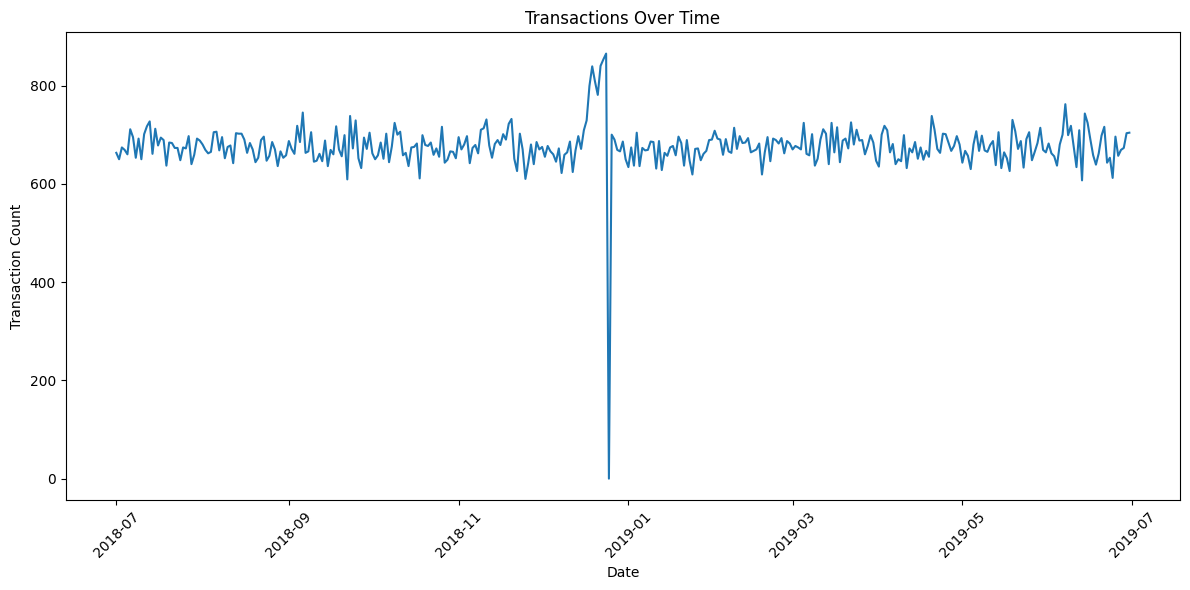

          DATE  Transaction_count
177 2018-12-25                0.0


In [40]:
# Create a complete sequence of dates from 1 Jul 2018 to 30 Jun 2019

all_dates = pd.DataFrame({
    "DATE": pd.date_range(start="2018-07-01", end="2019-06-30")
})

# Merge with transaction counts by date
date_summary = all_dates.merge(
    transaction_by_date,
    on="DATE",
    how="left"
)

# Fill missing transaction counts with 0
date_summary["Transaction_count"] = date_summary["Transaction_count"].fillna(0)

# Plot transaction counts over time
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(date_summary["DATE"], date_summary["Transaction_count"])
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.title("Transactions Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identify missing dates
missing_dates = date_summary[date_summary["Transaction_count"] == 0]

print(missing_dates)

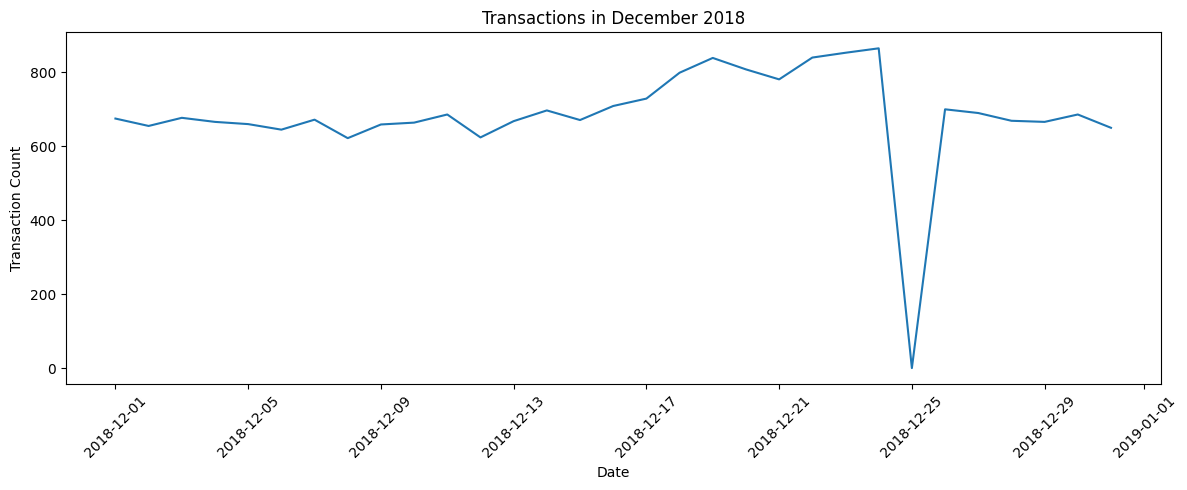

          DATE  Transaction_count
177 2018-12-25                0.0


In [43]:
# Zoom in on December period

december_data = date_summary[
    (date_summary["DATE"] >= "2018-12-01") &
    (date_summary["DATE"] <= "2018-12-31")
]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(december_data["DATE"], december_data["Transaction_count"])
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.title("Transactions in December 2018")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Highlight missing or zero transaction days in December
print(december_data[december_data["Transaction_count"] == 0])

In [47]:
import re

# Extract pack size (numbers) from PROD_NAME
transactions["PACK_SIZE"] = transactions["PROD_NAME"].str.extract(r"(\d+\.?\d*)").astype(float)

# Check if pack sizes look sensible
pack_size_summary = (
    transactions.groupby("PACK_SIZE")
      .size()
      .reset_index(name="count")
      .sort_values("PACK_SIZE")
)

print(pack_size_summary)

    PACK_SIZE  count
0        70.0   1507
1        90.0   3008
2       110.0  22387
3       125.0   1454
4       134.0  25102
5       135.0   3257
6       150.0  40203
7       160.0   2970
8       165.0  15297
9       170.0  19983
10      175.0  66390
11      180.0   1468
12      190.0   2995
13      200.0   4473
14      210.0   6272
15      220.0   1564
16      250.0   3169
17      270.0   6285
18      330.0  12540
19      380.0   6416


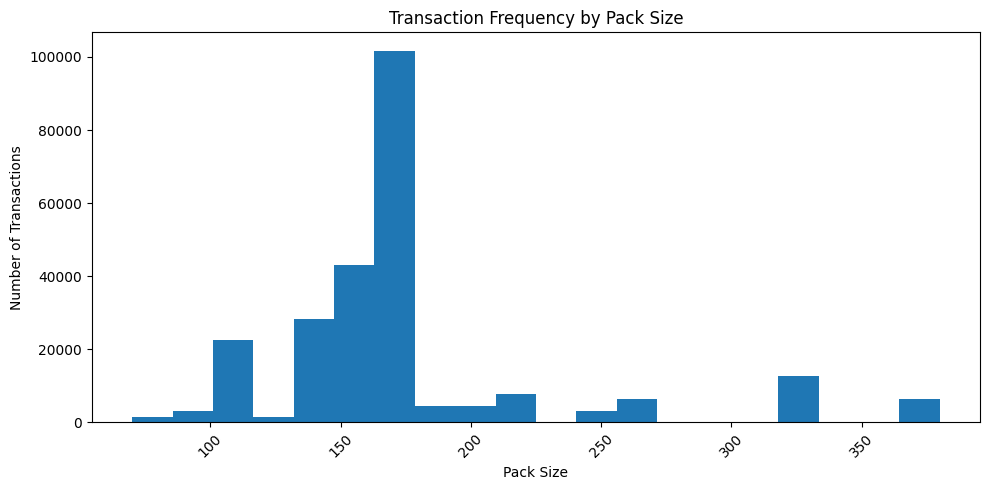

In [49]:
import matplotlib.pyplot as plt

# Plot histogram of PACK_SIZE (treating as categorical frequency distribution)
plt.figure(figsize=(10, 5))
plt.hist(transactions["PACK_SIZE"].dropna(), bins=len(transactions["PACK_SIZE"].unique()))

plt.xlabel("Pack Size")
plt.ylabel("Number of Transactions")
plt.title("Transaction Frequency by Pack Size")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [50]:
# Create brand name by taking the first word of PROD_NAME

transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0]

# Check results
print(transactions["BRAND"].value_counts())

BRAND
Kettle        41288
Smiths        27390
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64


In [51]:
# Standardise brand names

brand_map = {
    "Dorito": "Doritos",
    "RRD": "Red",
    "Red": "Red",
    "WW": "Woolworths",
    "Woolworths": "Woolworths",
    "Smith": "Smiths",
    "Infzns": "Infuzions",
    "GrnWves": "Grain",
    "Grain": "Grain",
    "NCC": "Natural",
    "Natural": "Natural"
}

transactions["BRAND"] = transactions["BRAND"].replace(brand_map)

# Check cleaned brand distribution
print(transactions["BRAND"].value_counts())

BRAND
Kettle        41288
Smiths        30353
Doritos       25224
Pringles      25102
Red           16321
Infuzions     14201
Thins         14075
Woolworths    11836
Cobs           9693
Tostitos       9471
Twisties       9454
Grain          7740
Natural        7469
Tyrrells       6442
Cheezels       4603
CCs            4551
Cheetos        2927
Snbts          1576
Burger         1564
Sunbites       1432
French         1418
Name: count, dtype: int64


In [57]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [56]:
customers['LIFESTAGE'].value_counts().sort_values()
customers['PREMIUM_CUSTOMER'].value_counts().sort_values()

PREMIUM_CUSTOMER
Premium       18922
Budget        24470
Mainstream    29245
Name: count, dtype: int64

In [62]:
merge = transactions.merge(
    customers,
    on="LYLTY_CARD_NBR",
    how="left"
)

merge.head()


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [63]:
merge.shape

(246740, 12)

In [68]:
# Check transactions without a matched customer (missing join)

missing_customers = merge[merge.isna().any(axis=1)]

print("Number of unmatched transactions:", missing_customers.shape[0])

# Show a few examples
print(missing_customers.head())

Number of unmatched transactions: 0
Empty DataFrame
Columns: [DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES, PACK_SIZE, BRAND, LIFESTAGE, PREMIUM_CUSTOMER]
Index: []


In [69]:
# Save merged dataset as CSV

merge.to_csv("QVI_data.csv", index=False)

                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
0   MIDAGE SINGLES/COUPLES           Budget   33345.70
1   MIDAGE SINGLES/COUPLES       Mainstream   84734.25
2   MIDAGE SINGLES/COUPLES          Premium   54443.85
3             NEW FAMILIES           Budget   20607.45
4             NEW FAMILIES       Mainstream   15979.70
5             NEW FAMILIES          Premium   10760.80
6           OLDER FAMILIES           Budget  156863.75
7           OLDER FAMILIES       Mainstream   96413.55
8           OLDER FAMILIES          Premium   75242.60
9    OLDER SINGLES/COUPLES           Budget  127833.60
10   OLDER SINGLES/COUPLES       Mainstream  124648.50
11   OLDER SINGLES/COUPLES          Premium  123537.55
12                RETIREES           Budget  105916.30
13                RETIREES       Mainstream  145168.95
14                RETIREES          Premium   91296.65
15          YOUNG FAMILIES           Budget  129717.95
16          YOUNG FAMILIES       Mainstream   86338.25
17        

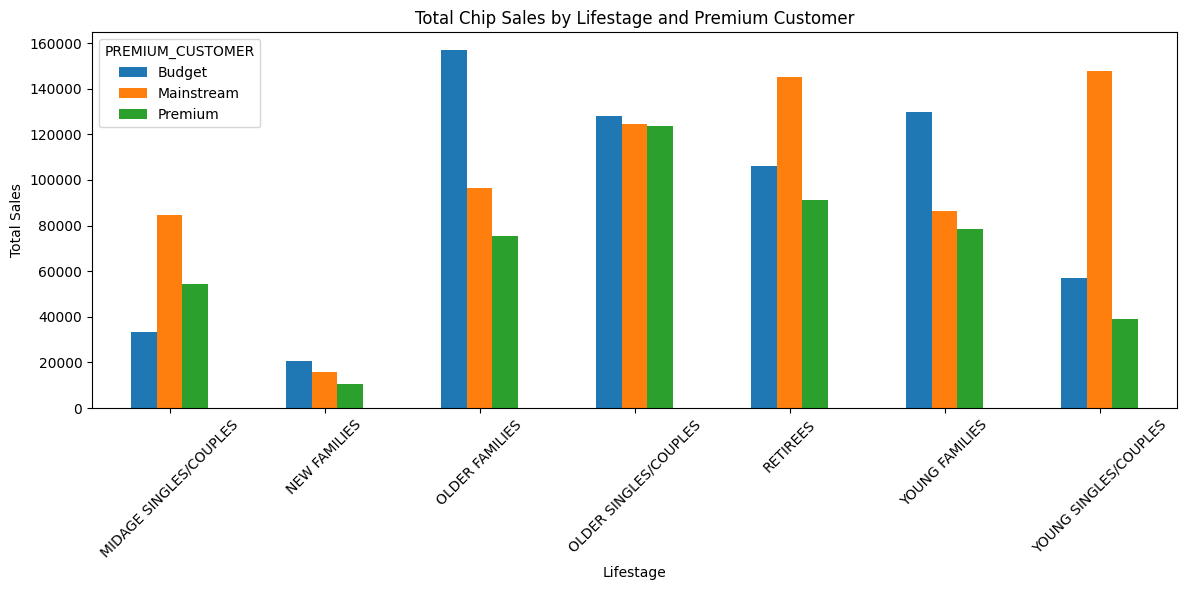

In [72]:

# Group by LIFESTAGE and PREMIUM_CUSTOMER
sales_by_segment = (
    merge.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"]
    .sum()
    .reset_index()
)

print(sales_by_segment)

# Pivot for plotting
pivot_sales = sales_by_segment.pivot(
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    values="TOT_SALES"
).fillna(0)

# Plot
pivot_sales.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")
plt.title("Total Chip Sales by Lifestage and Premium Customer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                 LIFESTAGE PREMIUM_CUSTOMER  num_customers
0   MIDAGE SINGLES/COUPLES           Budget           1474
1   MIDAGE SINGLES/COUPLES       Mainstream           3298
2   MIDAGE SINGLES/COUPLES          Premium           2369
3             NEW FAMILIES           Budget           1087
4             NEW FAMILIES       Mainstream            830
5             NEW FAMILIES          Premium            575
6           OLDER FAMILIES           Budget           4611
7           OLDER FAMILIES       Mainstream           2788
8           OLDER FAMILIES          Premium           2231
9    OLDER SINGLES/COUPLES           Budget           4849
10   OLDER SINGLES/COUPLES       Mainstream           4858
11   OLDER SINGLES/COUPLES          Premium           4682
12                RETIREES           Budget           4385
13                RETIREES       Mainstream           6358
14                RETIREES          Premium           3812
15          YOUNG FAMILIES           Budget           39

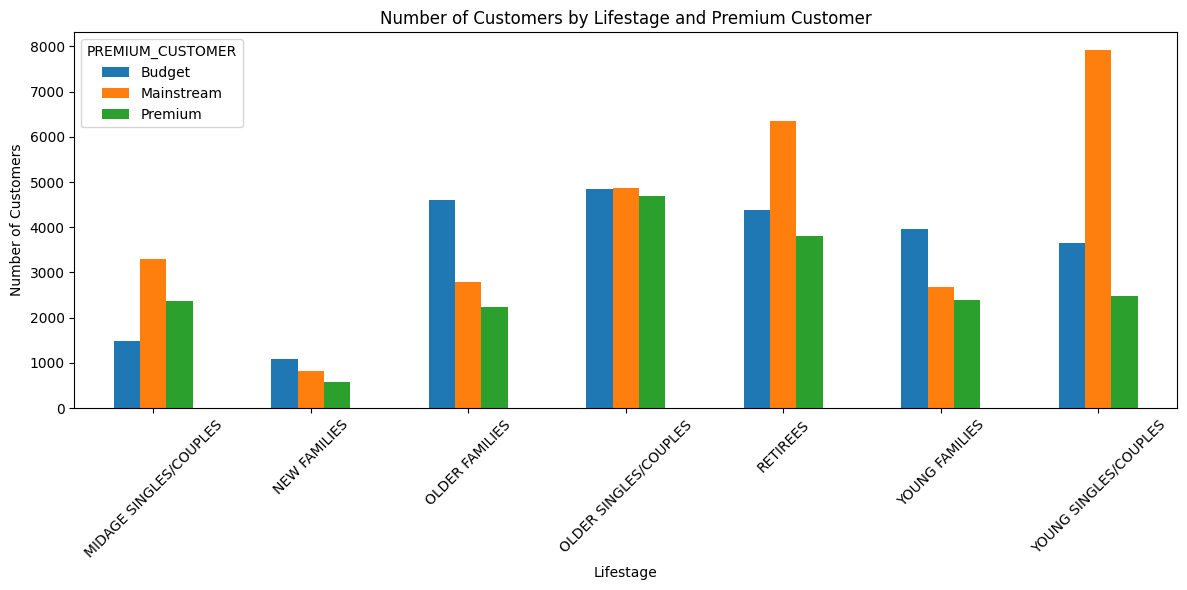

In [74]:
# Count number of unique customers per segment
customers_by_segment = (
    merge.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"]
    .nunique()
    .reset_index(name="num_customers")
)

print(customers_by_segment)

# Pivot for plotting
pivot_customers = customers_by_segment.pivot(
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    values="num_customers"
).fillna(0)

# Plot
pivot_customers.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Lifestage")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by Lifestage and Premium Customer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                 LIFESTAGE PREMIUM_CUSTOMER  total_units  num_customers  \
0   MIDAGE SINGLES/COUPLES           Budget         8883           1474   
1   MIDAGE SINGLES/COUPLES       Mainstream        21213           3298   
2   MIDAGE SINGLES/COUPLES          Premium        14400           2369   
3             NEW FAMILIES           Budget         5241           1087   
4             NEW FAMILIES       Mainstream         4060            830   
5             NEW FAMILIES          Premium         2769            575   
6           OLDER FAMILIES           Budget        41853           4611   
7           OLDER FAMILIES       Mainstream        25804           2788   
8           OLDER FAMILIES          Premium        20239           2231   
9    OLDER SINGLES/COUPLES           Budget        32883           4849   
10   OLDER SINGLES/COUPLES       Mainstream        32607           4858   
11   OLDER SINGLES/COUPLES          Premium        31695           4682   
12                RETIREE

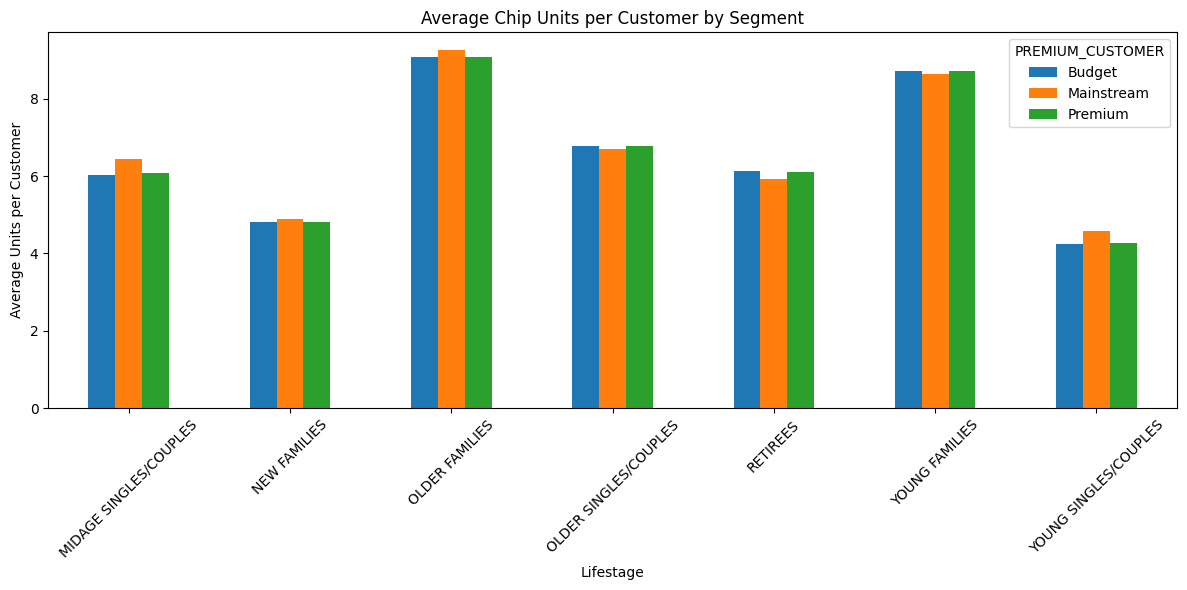

In [76]:
# Total units per segment
units_by_segment = (
    merge.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PROD_QTY"]
    .sum()
    .reset_index(name="total_units")
)

# Number of customers per segment
customers_by_segment = (
    merge.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"]
    .nunique()
    .reset_index(name="num_customers")
)

# Merge to compute average units per customer
avg_units = units_by_segment.merge(
    customers_by_segment,
    on=["LIFESTAGE", "PREMIUM_CUSTOMER"]
)

avg_units["avg_units_per_customer"] = avg_units["total_units"] / avg_units["num_customers"]

print(avg_units)

# Pivot for plotting
pivot_avg_units = avg_units.pivot(
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    values="avg_units_per_customer"
).fillna(0)

# Plot
pivot_avg_units.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Lifestage")
plt.ylabel("Average Units per Customer")
plt.title("Average Chip Units per Customer by Segment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                 LIFESTAGE PREMIUM_CUSTOMER  total_sales  total_units  \
0   MIDAGE SINGLES/COUPLES           Budget     33345.70         8883   
1   MIDAGE SINGLES/COUPLES       Mainstream     84734.25        21213   
2   MIDAGE SINGLES/COUPLES          Premium     54443.85        14400   
3             NEW FAMILIES           Budget     20607.45         5241   
4             NEW FAMILIES       Mainstream     15979.70         4060   
5             NEW FAMILIES          Premium     10760.80         2769   
6           OLDER FAMILIES           Budget    156863.75        41853   
7           OLDER FAMILIES       Mainstream     96413.55        25804   
8           OLDER FAMILIES          Premium     75242.60        20239   
9    OLDER SINGLES/COUPLES           Budget    127833.60        32883   
10   OLDER SINGLES/COUPLES       Mainstream    124648.50        32607   
11   OLDER SINGLES/COUPLES          Premium    123537.55        31695   
12                RETIREES           Budget    1059

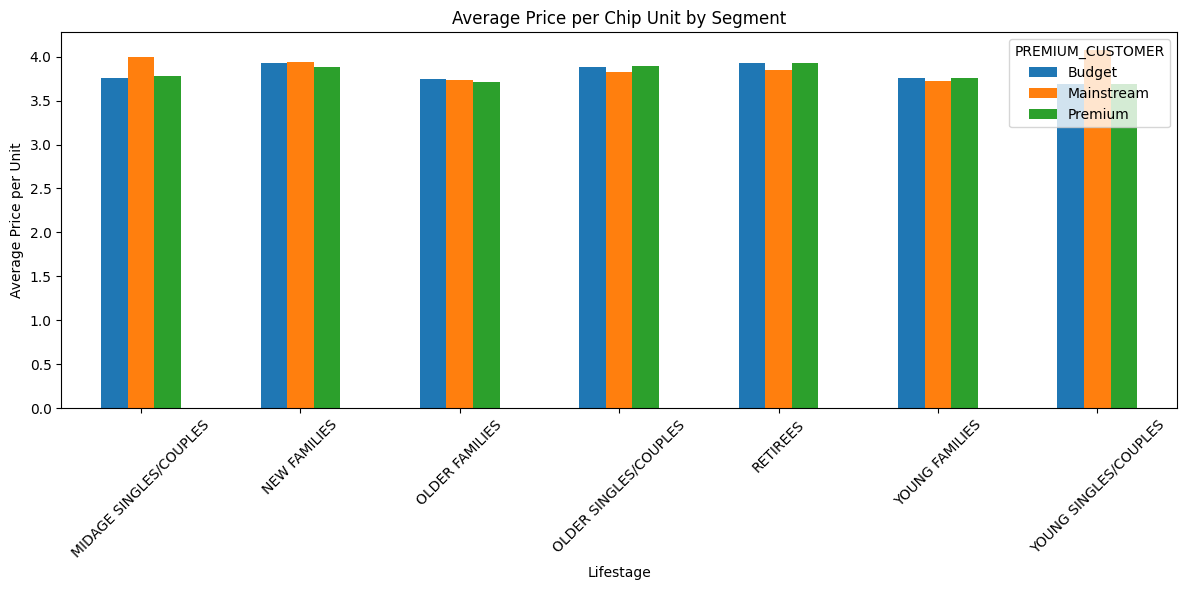

In [78]:
# Compute total sales and total units per segment
segment_summary = (
    merge.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])
    .agg(
        total_sales=("TOT_SALES", "sum"),
        total_units=("PROD_QTY", "sum")
    )
    .reset_index()
)

# Average price per unit = total sales / total units
segment_summary["avg_price_per_unit"] = (
    segment_summary["total_sales"] / segment_summary["total_units"]
)

print(segment_summary)

# Pivot for plotting
pivot_price = segment_summary.pivot(
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    values="avg_price_per_unit"
).fillna(0)

# Plot
pivot_price.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Lifestage")
plt.ylabel("Average Price per Unit")
plt.title("Average Price per Chip Unit by Segment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
from scipy import stats

# Create average price per unit at transaction level (if not already present)
merge["price_per_unit"] = merge["TOT_SALES"] / merge["PROD_QTY"]

# -----------------------------
# 1. Mainstream vs Premium (excluding Budget to keep clean comparison)
# -----------------------------

mainstream = merge[merge["PREMIUM_CUSTOMER"] == "Mainstream"]["price_per_unit"]
premium = merge[merge["PREMIUM_CUSTOMER"] == "Premium"]["price_per_unit"]

t_stat1, p_val1 = stats.ttest_ind(mainstream, premium, equal_var=False)

print("Mainstream vs Premium t-test")
print("t-statistic:", t_stat1)
print("p-value:", p_val1)

# -----------------------------
# 2. Midage vs Young Singles/Couples (within Premium Customer = Mainstream segment if needed)
# -----------------------------

midage = merge[merge["LIFESTAGE"] == "MIDAGE SINGLES/COUPLES"]["price_per_unit"]
young = merge[merge["LIFESTAGE"] == "YOUNG SINGLES/COUPLES"]["price_per_unit"]

t_stat2, p_val2 = stats.ttest_ind(midage, young, equal_var=False)

print("\nMidage vs Young Singles/Couples t-test")
print("t-statistic:", t_stat2)
print("p-value:", p_val2)

Mainstream vs Premium t-test
t-statistic: 11.05723574336507
p-value: 2.078836404118796e-28

Midage vs Young Singles/Couples t-test
t-statistic: -2.476347460961745
p-value: 0.013276709769200224


In [97]:
target = merge[
    (merge["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") &
    (merge["PREMIUM_CUSTOMER"] == "Mainstream")
]

rest = merge.drop(target.index)

In [98]:
target_brand = target["BRAND"].value_counts(normalize=True)
rest_brand = rest["BRAND"].value_counts(normalize=True)

brand_affinity = pd.DataFrame({
    "target_share": target_brand,
    "rest_share": rest_brand
}).fillna(0)

brand_affinity["lift"] = brand_affinity["target_share"] / brand_affinity["rest_share"]
brand_affinity = brand_affinity.sort_values("lift", ascending=False)

print(brand_affinity.head(10))

           target_share  rest_share      lift
BRAND                                        
Tyrrells       0.031672    0.025630  1.235751
Twisties       0.046050    0.037650  1.223096
Doritos        0.121725    0.100552  1.210572
Tostitos       0.045538    0.037769  1.205700
Kettle         0.196684    0.164809  1.193406
Pringles       0.118451    0.100297  1.181003
Cobs           0.044208    0.038861  1.137600
Infuzions      0.063958    0.057004  1.122003
Grain          0.033054    0.031224  1.058592
Thins          0.059660    0.056819  1.050009


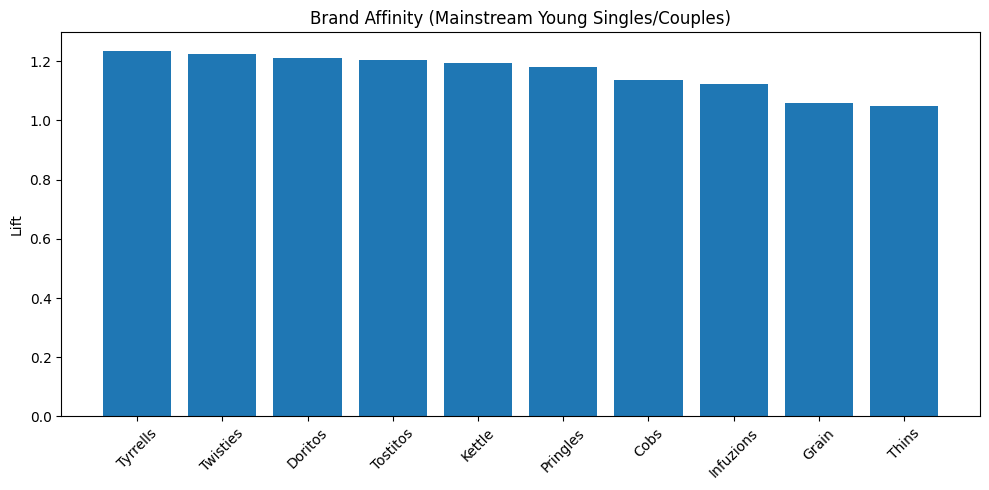

In [99]:
import matplotlib.pyplot as plt

top = brand_affinity.head(10)

plt.figure(figsize=(10,5))
plt.bar(top.index, top["lift"])
plt.title("Brand Affinity (Mainstream Young Singles/Couples)")
plt.ylabel("Lift")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We observe that Mainstream Young Singles/Couples show a clear preference for premium and popular snack brands. Tyrrells has the highest lift (1.24), followed by Twisties (1.22), Doritos (1.21), and Tostitos (1.21), indicating that this segment over-indexes on these brands compared to the rest of the population.

Notably, well-known mainstream brands such as Kettle, Pringles, and Doritos also show consistently elevated lift values (>1.18), suggesting that this segment is more brand-conscious and tends to prefer established, higher-quality chip brands rather than budget alternatives.

In [100]:
target_pack = target["PACK_SIZE"].value_counts(normalize=True)
rest_pack = rest["PACK_SIZE"].value_counts(normalize=True)

pack_affinity = pd.DataFrame({
    "target_share": target_pack,
    "rest_share": rest_pack
}).fillna(0)

pack_affinity["lift"] = pack_affinity["target_share"] / pack_affinity["rest_share"]
pack_affinity = pack_affinity.sort_values("lift", ascending=False)

print(pack_affinity)

           target_share  rest_share      lift
PACK_SIZE                                    
270.0          0.031723    0.024934  1.272269
380.0          0.032030    0.025485  1.256849
330.0          0.061144    0.049935  1.224477
134.0          0.118451    0.100297  1.181003
210.0          0.029472    0.025071  1.175546
110.0          0.104943    0.089509  1.172431
135.0          0.014838    0.013059  1.136234
250.0          0.014327    0.012716  1.126673
170.0          0.080587    0.081023  0.994629
150.0          0.157593    0.163396  0.964484
175.0          0.255679    0.270220  0.946189
165.0          0.056386    0.062479  0.902471
190.0          0.007573    0.012531  0.604312
180.0          0.003582    0.006153  0.582074
160.0          0.006549    0.012509  0.523568
90.0           0.006549    0.012676  0.516660
70.0           0.003223    0.006356  0.507178
125.0          0.003019    0.006140  0.491660
200.0          0.009159    0.018900  0.484594
220.0          0.003172    0.00661

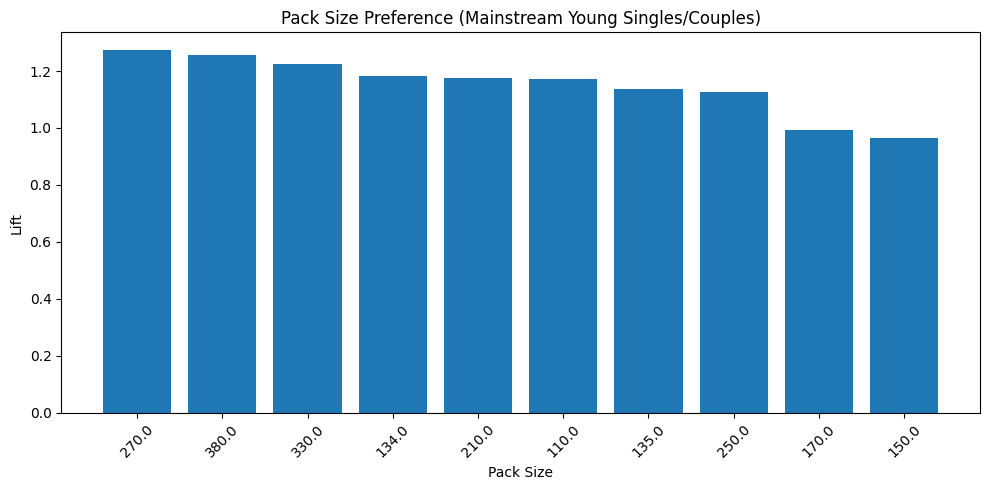

In [101]:
top_pack = pack_affinity.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_pack.index.astype(str), top_pack["lift"])
plt.title("Pack Size Preference (Mainstream Young Singles/Couples)")
plt.xlabel("Pack Size")
plt.ylabel("Lift")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Mainstream Young Singles/Couples segment shows a clear preference for larger pack sizes. Packs such as 270g, 380g, and 330g have the highest lift values (>1.20), indicating strong over-representation compared to the general population.

In contrast, standard and smaller pack sizes such as 150g, 165g, and 175g are under-indexed (lift < 1), suggesting that this segment is less likely to purchase regular single-serve packs.

Overall, this indicates that the segment tends to prefer bulk purchases, potentially reflecting higher consumption levels or sharing behaviour.